### Model Training

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Algerian_forest_fires_dataset_CLEANED.csv")
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


We do not need day, month and year, and since we will be working of Regression, we will be using only FWI and not Classes

In [5]:
df.drop(['month', 'day', 'year'], axis=1, inplace = True)

In [6]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [8]:
df["Classes"].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [9]:
# Dependent and Independent Features
X = df.drop('FWI', axis=1)
y = df['FWI']

In [10]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.75, random_state=42)
X_train.shape, X_test.shape

((182, 11), (61, 11))

In [11]:
# Feature Selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

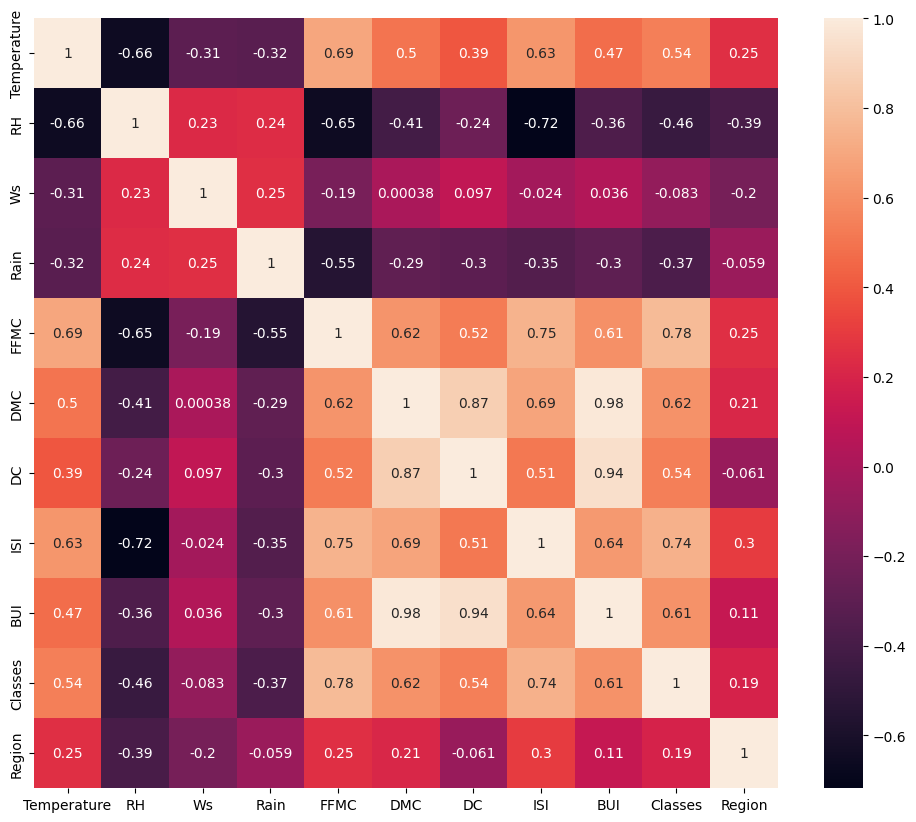

In [12]:
#check for multicollinearity
import seaborn as sns
plt.figure(figsize = (12,10))
sns.heatmap(X_train.corr(), annot = True)

In [13]:
#generalized function for getting collinear cols
def correlatoin(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j] > threshold):
                col_corr.add(corr_matrix.columns[i])
    return col_corr
corrFeat = correlatoin(X_train, 0.85) #this threshold is set by project managers or Domain Experts

In [14]:
#drop features when corr is more that 0.85
X_train.drop(corrFeat, axis = 1, inplace= True)
X_test.drop(corrFeat, axis = 1, inplace= True)

Feature scaling or Standardization

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
X_train_std

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

Box plot to understand the effect fo standard scaler

Text(0.5, 1.0, 'X_train after scaling')

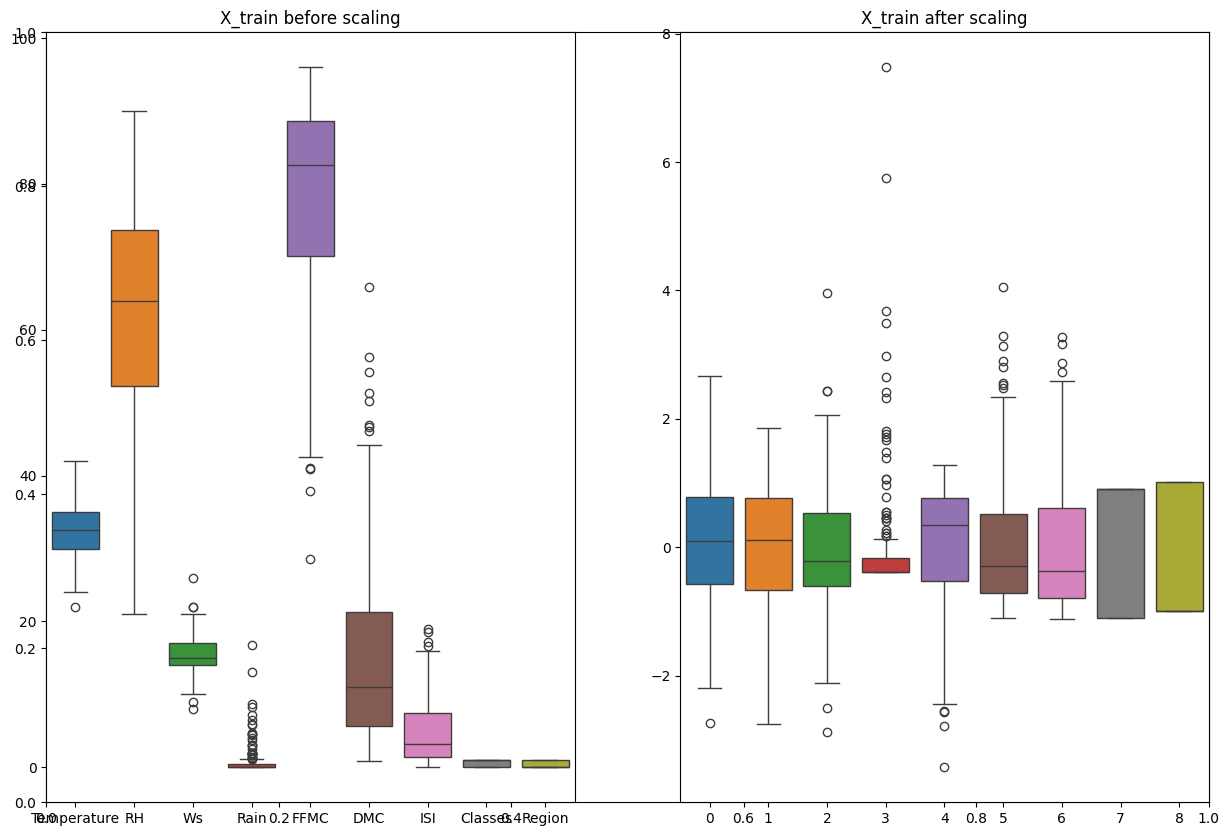

In [16]:
plt.subplots(figsize = (15, 10))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.title('X_train before scaling')
plt.subplot(1,2,2)
sns.boxplot(data=X_train_std)
plt.title("X_train after scaling")

Model Training

0.5468236465249978 0.9847657384266951


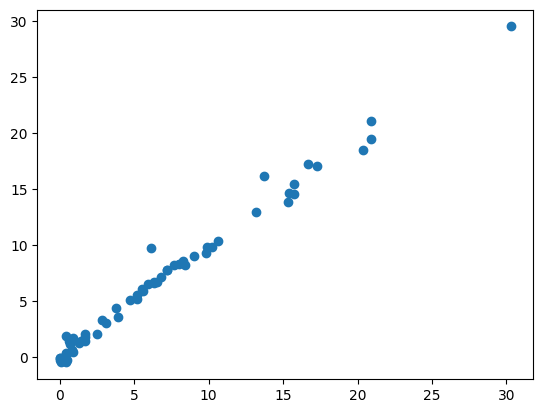

In [19]:
# Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
linReg = LinearRegression()
linReg.fit(X_train_std, y_train)
y_pred = linReg.predict(X_test_std)
linRegmae = mean_absolute_error(y_test, y_pred)
linRegscore = r2_score(y_test, y_pred)
print(linRegmae, linRegscore)
plt.scatter(y_test, y_pred)

1.1331759949144087 0.9492020263112388


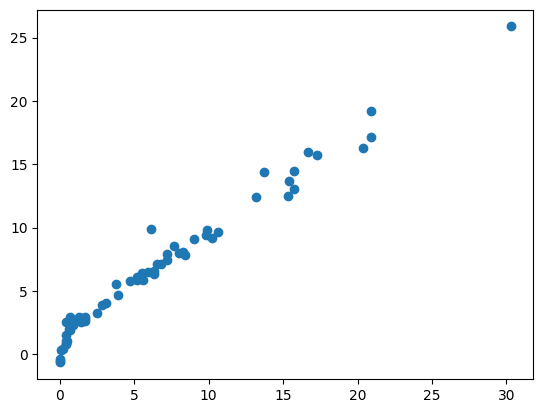

In [21]:
#Lasso Regression
from sklearn.linear_model import Lasso
lassoReg = Lasso()
lassoReg.fit(X_train_std, y_train)
y_pred = lassoReg.predict(X_test_std)
lassoRegmae = mean_absolute_error(y_test, y_pred)
lassoRegscore = r2_score(y_test, y_pred)
print(lassoRegmae, lassoRegscore)
plt.scatter(y_test, y_pred)

0.5642305340105715 0.9842993364555512


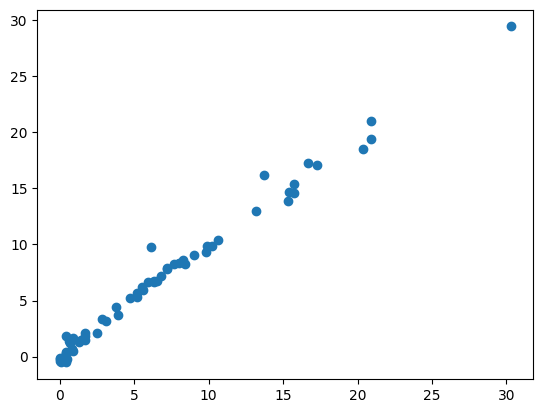

In [22]:
#Ridge Regression
from sklearn.linear_model import Ridge
ridgeReg = Ridge()
ridgeReg.fit(X_train_std, y_train)
y_pred = ridgeReg.predict(X_test_std)
ridgeRegmae = mean_absolute_error(y_test, y_pred)
ridgeRegscore = r2_score(y_test, y_pred)
print(ridgeRegmae, ridgeRegscore)
plt.scatter(y_test, y_pred)

1.8822353634895999 0.8753460589519703


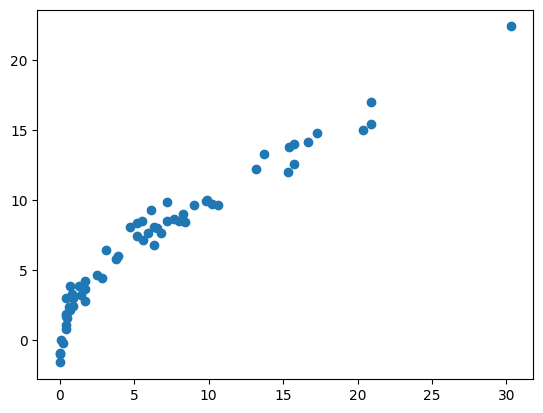

In [23]:
#ElasticNet Regression
from sklearn.linear_model import ElasticNet
elasticNetReg = ElasticNet()
elasticNetReg.fit(X_train_std, y_train)
y_pred = elasticNetReg.predict(X_test_std)
elasticNetRegmae = mean_absolute_error(y_test, y_pred)
elasticNetRegscore = r2_score(y_test, y_pred)
print(elasticNetRegmae, elasticNetRegscore)
plt.scatter(y_test, y_pred)

Hyperparameter Tuning

0.6358894638564663 0.9814406737205228
0.06582808719529475


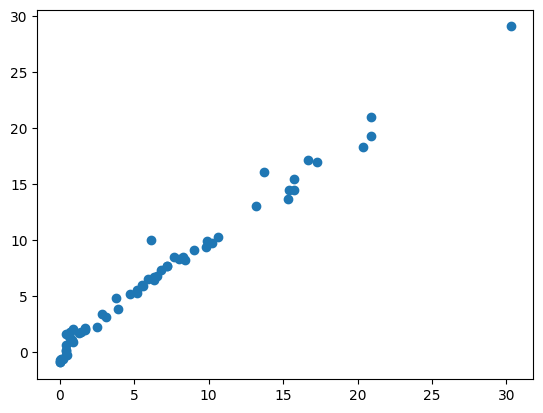

In [ ]:
#Lasso cv
from sklearn.linear_model import LassoCV
lassoReg = LassoCV()
lassoReg.fit(X_train_std, y_train)
y_pred = lassoReg.predict(X_test_std)
lassoRegmae = mean_absolute_error(y_test, y_pred)
lassoRegscore = r2_score(y_test, y_pred)
print(lassoRegmae, lassoRegscore)
print(lassoReg.alpha_)
plt.scatter(y_test, y_pred)

0.5642305340105715 0.9842993364555512


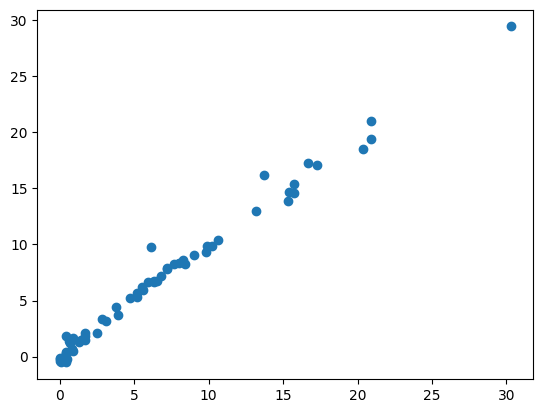

In [25]:
#Ridge Regression
from sklearn.linear_model import RidgeCV
ridgeReg = RidgeCV(cv=5)
ridgeReg.fit(X_train_std, y_train)
y_pred = ridgeReg.predict(X_test_std)
ridgeRegmae = mean_absolute_error(y_test, y_pred)
ridgeRegscore = r2_score(y_test, y_pred)
print(ridgeRegmae, ridgeRegscore)
plt.scatter(y_test, y_pred)

0.6575946731430901 0.9814217587854941
0.5 0.04311146156383891


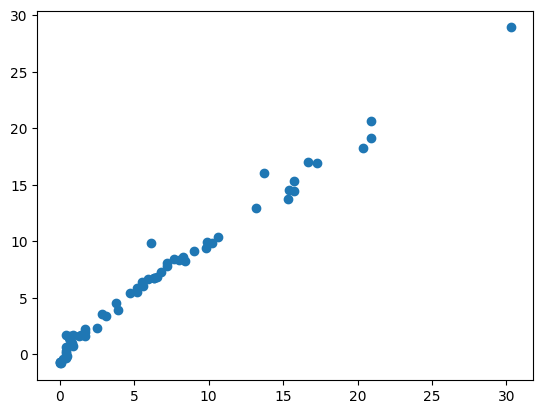

In [28]:
#ElasticNetcv Regression
from sklearn.linear_model import ElasticNetCV
elasticNetReg = ElasticNetCV()
elasticNetReg.fit(X_train_std, y_train)
y_pred = elasticNetReg.predict(X_test_std)
elasticNetRegmae = mean_absolute_error(y_test, y_pred)
elasticNetRegscore = r2_score(y_test, y_pred)
print(elasticNetRegmae, elasticNetRegscore)
print(elasticNetReg.l1_ratio_, elasticNetReg.alpha_)
plt.scatter(y_test, y_pred)